# STAT 230A Project: Firm Ownership and Wage Premia in Hungary
### Oliver Maynard & Mark Szekacs
---

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Load Data

In [2]:
df = pd.read_csv('../data/berek.csv', low_memory=False)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (264747, 104)


,tipv,tsz,teaor2008_4,telaz5,fforma,nem,msz,eszab,henora,hofora,etido,tora,belho,szakkepz,feor2008_4,kulcs,ober,hober,brutto,repreju,jutalek,tulmu,muejpot,eberpot_b,rejov,nerejove,prejue,hber,ker1,ker,kshreg,megye,lnkov,gfo2011_3,atip,ttip,ara,kra,file,azon,dupl,szk_bor,ofo_v1,ffo_v1,sfo_v1,rofo_v1,rffo_v1,rsfo_v1,ara_bor,kra_bor,...,szesu_v1,rfiz_v1,rsze_v1,rfizsu_v1,rszesu_v1,vall,ev,teaor2008_2,teaor2008_3,letszam_bv1,vkat_bv1,lkat_bv1,kol,ksz,telaz4,tazon,bpest,szulho,szulev,szulevho,kor,szolgho,szolgev,ujbel,iskveg9,iskveg5,iskev,szakm,kozepf,felsof,exp,exp2,tulmud,muejpotd,lnker,flag_gfo2011_3,ag1,ag2,tip,ugyora,alapi_b,ikieg,vezpot,epot_b,ugy,muejhepot,reker_b,lnko,muejhepotd,esuly
0,1.0000,10003035,2120,5467,1,0,1,30,40,168,0,0,0,94,3622,37,0.0000,570000.0000,570000,0.0000,0.0000,0,0.0000,0.0000,0,0,0,570000,570000,570000,1,1,92.0000,114.0000,4,3,3.0000,2.0000,14,4127992,0,2120.0000,1529,667,862,1,0,1,3.0000,2.0000,...,9.6854,0,1,0.0000,1.0000,1,2014,21,212,1530,6.0000,6.0000,1.0000,0.0000,546,1357,1,11,1965,70.0000,49,215,17.9167,0,9,5,17,0,0,1,26.0000,676.0000,0,0.0000,13.2534,NaN,3,6.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.6854
1,1.0000,10003035,2120,5467,1,0,1,35,40,168,0,0,0,94,2117,37,0.0000,447500.0000,447500,0.0000,0.0000,0,0.0000,0.0000,0,0,0,447500,447500,447500,1,1,92.0000,114.0000,4,3,3.0000,2.0000,14,4127993,0,2120.0000,1529,667,862,1,0,1,3.0000,2.0000,...,9.6854,0,1,0.0000,1.0000,1,2014,21,212,1530,6.0000,6.0000,1.0000,0.0000,546,1357,1,1,1982,264.0000,32,43,3.5833,0,9,5,17,0,0,1,9.0000,81.0000,0,0.0000,13.0114,NaN,3,6.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.6854
2,1.0000,10003035,2120,5467,1,1,1,30,40,180,0,12,0,71,3135,57,0.0000,288000.0000,524544,0.0000,0.0000,40433,110035.0000,51636.0000,0,24000,0,288000,374076,524544,1,1,92.0000,114.0000,4,3,3.0000,2.0000,14,4127994,0,2120.0000,1529,667,862,1,0,1,3.0000,2.0000,...,9.6854,0,1,0.0000,1.0000,1,2014,21,212,1530,6.0000,6.0000,1.0000,0.0000,546,1357,1,3,1956,-46.0000,58,131,10.9167,0,7,4,13,0,1,0,39.0000,1521.0000,1,1.0000,13.1703,NaN,3,6.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.6854


## 2. Rename Variables

Translating the Hungarian dataset into English via column mapping

In [3]:
rename_dict = {
    # --- Identifiers ---
    'azon':           'obs_id',
    'tsz':            'firm_id',
    'tazon':          'firm_obs_id',
    'dupl':           'duplicate_flag',
    'ev':             'year',
    'file':           'survey_subgroup',
    'belho':          'survey_month',
    # --- Sampling ---
    'esuly':          'sampling_weight',
    # --- Firm characteristics ---
    'tipv':           'firm_size_stratum',
    'lnko':           'firm_size_cat',
    'lnkov':          'firm_size_n',
    'vkat_bv1':       'firm_size_cat8',
    'lkat_bv1':       'firm_size_cat8_log',
    'letszam_bv1':    'firm_size_v1',
    'gfo2011_3':      'legal_form',
    'atip':           'employment_sector',
    'ara':            'state_ownership',
    'kra':            'foreign_ownership',
    'ara_bor':        'state_ownership_adj',
    'kra_bor':        'foreign_ownership_adj',
    'kol':            'collective_agreement',
    'ksz':            'union_presence',
    'vall':           'valid_firm_id',
    # --- Industry / Occupation ---
    'teaor2008_4':    'nace_4digit',
    'teaor2008_3':    'nace_3digit',
    'teaor2008_2':    'nace_2digit',
    'ag1':            'industry_broad',
    'ag2':            'industry_detail',
    'feor2008_4':     'occupation_4digit',
    'kulcs':          'position_category',
    'eszab':          'pay_grade',
    # --- Location ---
    'kshreg':         'nuts2_region',
    'megye':          'county',
    'ttip':           'settlement_type',
    'bpest':          'budapest',
    'telaz5':         'locality_code5',
    'telaz4':         'locality_code4',
    # --- Worker demographics ---
    'nem':            'sex',
    'kor':            'age',
    'szulev':         'birth_year',
    'szulevho':       'birth_year_month',
    'szulho':         'birth_place',
    # --- Education ---
    'iskveg9':        'education_9cat',
    'iskveg5':        'education_5cat',
    'iskev':          'schooling_years',
    'szakkepz':       'vocational_qual',
    'szakm':          'vocational_training',
    'kozepf':         'secondary_educ',
    'felsof':         'tertiary_educ',
    # --- Experience & tenure ---
    'exp':            'experience',
    'exp2':           'experience_sq',
    'szolgev':        'tenure_years',
    'szolgho':        'tenure_months',
    'ujbel':          'new_hire',
    # --- Employment type ---
    'fforma':         'employment_type',
    'msz':            'contract_type',
    'etido':          'fulltime',
    'ober':           'hourly_pay_flag',
    'hober':          'monthly_pay_flag',
    'kag':            'any_supplement',
    # --- Working time ---
    'hofora':         'contracted_hours_month',
    'tora':           'overtime_hours',
    'tulmud':         'overtime_dummy',
    'ugyora':         'case_hours',
    'ugy':            'case_count',
    # --- Earnings ---
    'brutto':         'gross_wage',
    'repreju':        'regular_gross_pay',
    'jutalek':        'commission',
    'tulmu':          'overtime_pay',
    'muejpot':        'shift_allowance',
    'muejpotd':       'shift_allowance_dummy',
    'muejhepot':      'shift_hourly_supplement',
    'muejhepotd':     'shift_hourly_supplement_dummy',
    'eberpot_b':      'other_hourly_supplement',
    'rejov':          'regular_income',
    'nerejove':       'irregular_income',
    'prejue':         'total_regular_gross',
    'hber':           'monthly_wage',
    'henora':         'hourly_wage_contracted',
    'alapi_b':        'base_wage',
    'ikieg':          'supplementary_pay',
    'vezpot':         'management_supplement',
    'epot_b':         'other_supplement',
    'reker_b':        'regular_earnings_base',
    'ker1':           'earnings1',
    'ker':            'earnings',
    'lnker':          'log_earnings',
    # --- Derived v1 series ---
    'ofo_v1':         'occ_mean_wage_v1',
    'ffo_v1':         'firm_mean_wage_v1',
    'sfo_v1':         'sector_mean_wage_v1',
    'rofo_v1':        'occ_wage_resid_v1',
    'rffo_v1':        'firm_wage_resid_v1',
    'rsfo_v1':        'sector_wage_resid_v1',
    'szk_bor':        'occ_wage_envelope',
    'fiz_v1':         'pay_v1',
    'sze_v1':         'person_v1',
    'fizsu_v1':       'pay_sum_v1',
    'szesu_v1':       'person_sum_v1',
    'rfiz_v1':        'residual_pay_v1',
    'rsze_v1':        'residual_person_v1',
    'rfizsu_v1':      'residual_pay_sum_v1',
    'rszesu_v1':      'residual_person_sum_v1',
    # --- Other ---
    'tip':            'institution_level',
    'flag_gfo2011_3': 'ownership_flag',
}

df = df.rename(columns=rename_dict)
print(f'Columns after rename: {df.shape[1]}')

Columns after rename: 104


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_n': missing, 'missing_pct': missing_pct}).query('missing_n > 0').sort_values('missing_pct', ascending=False)

,missing_n,missing_pct
ownership_flag,264747,100.0000
management_supplement,194040,73.2900
institution_level,194040,73.2900
case_hours,194040,73.2900
base_wage,194040,73.2900
supplementary_pay,194040,73.2900
shift_hourly_supplement_dummy,194040,73.2900
other_supplement,194040,73.2900
case_count,194040,73.2900
shift_hourly_supplement,194040,73.2900


## 3. Drop Irrelevant Variables

In [5]:
cols_to_drop = [
    # Redundant earnings measures (keep: earnings, log_earnings)
    'gross_wage', 'regular_gross_pay', 'monthly_wage', 'hourly_wage_contracted',
    'earnings1', 'regular_income', 'irregular_income', 'total_regular_gross',
    'regular_earnings_base',
    # Earnings supplements (keep any_supplement dummy)
    'commission', 'overtime_pay', 'shift_allowance', 'shift_hourly_supplement',
    'other_hourly_supplement', 'supplementary_pay', 'management_supplement',
    'other_supplement', 'base_wage',
    # v1 derived series
    'occ_mean_wage_v1', 'firm_mean_wage_v1', 'sector_mean_wage_v1',
    'occ_wage_resid_v1', 'firm_wage_resid_v1', 'sector_wage_resid_v1',
    'occ_wage_envelope', 'pay_v1', 'person_v1', 'pay_sum_v1', 'person_sum_v1',
    'residual_pay_v1', 'residual_person_v1', 'residual_pay_sum_v1', 'residual_person_sum_v1',
    # Adjusted ownership (use raw)
    'state_ownership_adj', 'foreign_ownership_adj',
    # Redundant NACE/industry levels (occupation_6cat created from occupation_4digit)
    'nace_4digit', 'nace_3digit', 'nace_2digit', 'industry_detail',
    'occupation_4digit',
    # Redundant firm size (firm_size_4cat created from firm_size_v1)
    'firm_size_stratum', 'firm_size_cat8', 'firm_size_cat8_log', 'firm_size_cat', 'firm_size_n',
    # Redundant education (keep education_5cat only)
    'education_9cat', 'schooling_years', 'vocational_qual',
    'vocational_training', 'secondary_educ', 'tertiary_educ',
    # Redundant tenure (keep tenure_years)
    'tenure_months',
    # Redundant location (keep settlement_type, nuts2_region)
    'locality_code5', 'locality_code4', 'county', 'budapest',
    # Worker biography
    'birth_year', 'birth_year_month', 'birth_place',
    # Technical/admin
    'duplicate_flag', 'firm_obs_id', 'ownership_flag', 'valid_firm_id',
    'survey_month', 'survey_subgroup',
    # Not informative
    'employment_sector', 'institution_level',
    'case_hours', 'case_count',
    'hourly_pay_flag', 'monthly_pay_flag',
    'pay_grade',
    'shift_allowance_dummy', 'shift_hourly_supplement_dummy',
    # Additional drops
    'firm_id', 'legal_form', 'sampling_weight', 'obs_id', 'year',
]

df = df.drop(columns=cols_to_drop, errors='ignore')
print(f'Columns after dropping: {df.shape[1]}')
print(df.columns.tolist())

Columns after dropping: 25
['employment_type', 'sex', 'contract_type', 'contracted_hours_month', 'fulltime', 'overtime_hours', 'position_category', 'earnings', 'nuts2_region', 'settlement_type', 'state_ownership', 'foreign_ownership', 'any_supplement', 'firm_size_v1', 'collective_agreement', 'union_presence', 'age', 'tenure_years', 'new_hire', 'education_5cat', 'experience', 'experience_sq', 'overtime_dummy', 'log_earnings', 'industry_broad']


In [6]:
# employment_type itself dropped - fulltime dummy captures what we need
df = df.drop(columns=['employment_type'])

## 4. Recode Variables
### 4.1 Firm Size Recoding

Firm size is recoded into 4 categories aligned with the EU SME definition (European Commission Recommendation 2003/361/EC). Firm size is a well-documented predictor of wage premia: larger firms tend to pay more due to higher productivity and rent-sharing behaviour.

| Category | Employees |
|---|---|
| micro/small | <50 |
| medium | 50–249 |
| large | 250–499 |
| very large | 500+ |

In [7]:
def recode_firm_size(n):
    if pd.isna(n):      return np.nan
    elif n < 50:        return '1_micro_small'
    elif n < 250:       return '2_medium'
    elif n < 500:       return '3_large'
    else:               return '4_very_large'

df['firm_size_4cat'] = df['firm_size_v1'].apply(recode_firm_size)
print(df['firm_size_4cat'].value_counts(dropna=False))

firm_size_4cat
1_micro_small    110844
4_very_large      82497
2_medium          51930
3_large           19476
Name: count, dtype: int64


### 4.2 Ownership Type Recoding

The key explanatory variables are firm ownership type. From the raw dataset, state and foreign ownership share variables, so we construct two binary indicators for **majority** ownership, since majority control is the economically meaningful threshold at which ownership type 
plausibly affects wage-setting behaviour and firm governance.

Both ownership categories retain sufficient observations for inference: 39,661 workers are employed at foreign-majority firms and 17,649 at state-majority firms, against a domestic private baseline of roughly 207,000, ensuring that ownership-specific coefficient estimates will be well-identified.

In [8]:
# 1 = 100%, 2 = majority -> foreign/state majority dummy
df['foreign_majority'] = (df['foreign_ownership'].isin([1, 2])).astype(int)
df['state_majority']   = (df['state_ownership'].isin([1, 2])).astype(int)

# Drop raw ownership variables
df = df.drop(columns=['state_ownership', 'foreign_ownership'])

print(df['foreign_majority'].value_counts())
print(df['state_majority'].value_counts())

# Sanity check: overlap between foreign and state majority
print(f'\nBoth foreign and state majority: {((df["foreign_majority"] == 1) & (df["state_majority"] == 1)).sum()}')

foreign_majority
0    225086
1     39661
Name: count, dtype: int64
state_majority
0    247098
1     17649
Name: count, dtype: int64

Both foreign and state majority: 61


### Dropping Ambiguous Ownership Observations

61 observations are simultaneously coded as foreign-majority and state-majority owned, which is logically inconsistent. These likely reflect data entry errors or edge cases in the survey coding. Since they represent less than 0.03% of the sample, we drop them.

In [9]:
df = df[~((df['foreign_majority'] == 1) & (df['state_majority'] == 1))].copy()
print(f'Observations after dropping ambiguous ownership: {len(df)}')

Observations after dropping ambiguous ownership: 264686


### 4.3 Industry Recoding

The 21 NACE sections are collapsed into 13 economically meaningful groups to reduce dimensionality while preserving key sectoral distinctions relevant to wage-setting. Finance and real estate are grouped together, as are ICT and professional services, given their similar high-skill, high-wage profiles. Public administration, education, and health are kept separate due to their distinct wage-setting institutions in Hungary.

| Category | Sectors |
|---|---|
| `01_agriculture` | Agriculture, forestry, fishing |
| `02_mining_energy` | Mining, energy, water & waste |
| `03_manufacturing` | Manufacturing |
| `04_construction` | Construction |
| `05_trade` | Trade & vehicle repair |
| `06_transport` | Transport & storage |
| `07_hospitality` | Accommodation & food services |
| `08_finance` | Finance, insurance & real estate |
| `09_ict_professional` | ICT & professional/scientific services |
| `10_public_admin` | Public administration & defence |
| `11_education` | Education |
| `12_health_social` | Human health & social work |
| `13_other_services` | Admin support, arts, other services |

In [10]:
industry_map = {
    1:  '01_agriculture',
    2:  '02_mining_energy',
    4:  '02_mining_energy',
    5:  '02_mining_energy',
    3:  '03_manufacturing',
    6:  '04_construction',
    7:  '05_trade',
    8:  '06_transport',
    9:  '07_hospitality',
    11: '08_finance',
    12: '08_finance',
    10: '09_ict_professional',
    13: '09_ict_professional',
    15: '10_public_admin',
    16: '11_education',
    17: '12_health_social',
    14: '13_other_services',
    18: '13_other_services',
    19: '13_other_services',
    20: '13_other_services',
    21: '13_other_services',
}

df['industry_13cat'] = df['industry_broad'].map(industry_map)
df = df.drop(columns=['industry_broad'])
print(df['industry_13cat'].value_counts().sort_index())

industry_13cat
01_agriculture          7320
02_mining_energy        7583
03_manufacturing       49619
04_construction        10615
05_trade               32990
06_transport           14508
07_hospitality          6189
08_finance             11047
09_ict_professional    17142
10_public_admin        26235
11_education           38458
12_health_social       26224
13_other_services      16756
Name: count, dtype: int64


### 4.4 Position Category Recoding

The original position category variable distinguishes 24 fine-grained seniority and skill levels. We collapse these into 5 categories capturing the key hierarchical distinctions relevant to wage-setting. Note that this variable captures a different dimension from occupation: while occupation describes **what** a worker does, position category describes **where** they sit in the firm hierarchy.

| Category | Description |
|---|---|
| `1_top_management` | Chief executives and their deputies |
| `2_management` | Senior and middle managers |
| `3_professional` | Production supervisors and white-collar staff |
| `4_clerical` | Administrative and office workers |
| `5_manual` | Unskilled, semi-skilled, skilled workers and masters |

In [ ]:
position_map = {
    1:  '1_top_management',
    2:  '1_top_management',
    11: '2_management',
    12: '2_management',
    21: '3_professional',
    22: '3_professional',
    23: '3_professional',
    31: '3_professional',
    32: '3_professional',
    33: '3_professional',
    34: '3_professional',
    35: '3_professional',
    36: '3_professional',
    37: '3_professional',
    38: '3_professional',
    41: '4_clerical',
    42: '4_clerical',
    51: '5_manual',
    52: '5_manual',
    53: '5_manual',
    54: '5_manual',
    55: '5_manual',
    56: '5_manual',
    57: '5_manual',
    58: '5_manual',
}

df['position_5cat'] = df['position_category'].map(position_map)
print(df['position_5cat'].value_counts().sort_index())

position_5cat
1_top_management      4868
2_management          5821
3_professional       73112
4_clerical           10061
5_manual            100120
Name: count, dtype: int64


In [12]:
df[df['position_5cat'].isna()]['position_category'].value_counts()

position_category
888880    7208
602122    1029
602132     998
602112     908
602102     824
          ... 
319043       1
328023       1
325041       1
326112       1
328143       1
Name: count, Length: 2013, dtype: int64

Strange missingness in position category. In the data brief it is explicit about mapping but there appears to be 70,000 approximate rows that don't fit into any of the documented categories. Not much we can do about this.

In [13]:
df = df.drop(columns=['position_category'])

### 4.5 Total Hours Worked

We construct a single variable capturing total hours worked per month by summing contracted hours and overtime hours. Overtime is set to zero where missing, as the absence of a recorded value indicates no overtime was worked.

In [14]:
df['total_hours'] = df['contracted_hours_month'] + df['overtime_hours'].fillna(0)
df = df.drop(columns=['contracted_hours_month', 'overtime_hours'])
print(df['total_hours'].describe())

count   264686.0000
mean       166.1155
std         29.4261
min         63.0000
25%        168.0000
50%        174.0000
75%        176.0000
max        464.0000
Name: total_hours, dtype: float64


### Total Hours: Outlier Removal

Under the Hungarian Labour Code (Act I of 2012), the maximum weekly working time including overtime is capped at 48 hours, translating to approximately 209 hours per month. We apply a conservative cutoff of 220 hours to allow for minor scheduling variations and rounding in survey reporting, while still excluding observations that are implausible under any standard employment arrangement.

In [15]:
print('Total hours > 220:', (df['total_hours'] > 220).sum())

n_before = len(df)
df = df[df['total_hours'] <= 220].copy()
print(f'Observations dropped: {n_before - len(df)}')
print(f'Shape after: {df.shape}')

Total hours > 220: 4931
Observations dropped: 4931
Shape after: (259755, 24)


## Variable Encoding

All categorical and binary variables are explicitly labelled and converted to pandas `Categorical` type. This serves two purposes: it makes the data self-documenting by replacing numeric codes with descriptive English labels, and it ensures correct handling in downstream modelling where categorical variables must be distinguished from continuous ones.

In [16]:
# Contract type
contract_map = {1: 'permanent', 2: 'fixed_term', 3: 'apprentice', 4: 'other'}
df['contract_type'] = df['contract_type'].map(contract_map).astype('category')

# Settlement type
settlement_map = {1: 'capital', 2: 'town', 3: 'other'}
df['settlement_type'] = df['settlement_type'].map(settlement_map).astype('category')

# Education 5cat
education_map = {1: '1_primary_incomplete', 2: '2_primary', 3: '3_vocational', 
                 4: '4_secondary', 5: '5_tertiary'}
df['education_5cat'] = df['education_5cat'].map(education_map).astype('category')

# NUTS2 region
nuts2_map = {1: 'central_hungary', 2: 'central_transdanubia', 3: 'western_transdanubia',
             4: 'southern_transdanubia', 5: 'northern_hungary', 
             6: 'northern_great_plain', 7: 'southern_great_plain'}
df['nuts2_region'] = df['nuts2_region'].map(nuts2_map).astype('category')

for col in ['firm_size_4cat', 'industry_13cat', 'position_5cat']:
    df[col] = pd.Categorical(df[col])

print(df[['firm_size_4cat', 'industry_13cat', 'position_5cat']].dtypes)

# Binary variables
df['sex'] = df['sex'].map({0: 'female', 1: 'male'}).astype('category')
df['fulltime'] = df['fulltime'].map({0: 'part_time', 1: 'full_time'}).astype('category')
df['new_hire'] = df['new_hire'].map({0: 'existing', 1: 'new_hire'}).astype('category')
df['collective_agreement'] = df['collective_agreement'].map({0: 'no', 1: 'yes'}).astype('category')
df['union_presence'] = df['union_presence'].map({0: 'no', 1: 'yes'}).astype('category')
df['any_supplement'] = df['any_supplement'].map({0: 'no', 1: 'yes'}).astype('category')
df['foreign_majority'] = df['foreign_majority'].map({0: 'no', 1: 'yes'}).astype('category')
df['state_majority'] = df['state_majority'].map({0: 'no', 1: 'yes'}).astype('category')

print('Done.')

firm_size_4cat    category
industry_13cat    category
position_5cat     category
dtype: object
Done.


### Final Variable List

**Outcome**

| Variable | Description |
|---|---|
| `earnings` | Monthly gross earnings in HUF |
| `log_earnings` | Natural log of monthly gross earnings |

**Key Explanatory**

| Variable | Description |
|---|---|
| `foreign_majority` | Foreign-majority ownership (no / yes) |
| `state_majority` | State-majority ownership (no / yes) |

**Worker Characteristics**

| Variable | Description |
|---|---|
| `sex` | Sex of worker (female / male) |
| `age` | Age in years |
| `experience` | Potential labour market experience in years |
| `experience_sq` | Experience squared |
| `log_tenure` | Natural log of tenure years + 1 |
| `education_5cat` | Educational attainment (primary_incomplete / primary / vocational / secondary / tertiary) |
| `new_hire` | Hired within the past year (existing / new_hire) |

**Employment**

| Variable | Description |
|---|---|
| `contract_type` | Type of employment contract (permanent / fixed_term / apprentice / other) |
| `fulltime` | Full-time employment (full_time / part_time) |
| `total_hours` | Total hours worked per month (contracted + overtime) |
| `any_supplement` | Receives any wage supplement (no / yes) |

**Firm Characteristics**

| Variable | Description |
|---|---|
| `firm_size_4cat` | Firm size by EU SME definition (micro_small / medium / large / very_large) |
| `collective_agreement` | Collective bargaining agreement coverage (no / yes) |
| `union_presence` | Union or works council present at firm (no / yes) |

**Industry, Occupation & Location**

| Variable | Description |
|---|---|
| `industry_13cat` | Industry group (agriculture / mining_energy / manufacturing / construction / trade / transport / hospitality / finance / ict_professional / public_admin / education / health_social / other_services) |
| `position_5cat` | Position in firm hierarchy (top_management / management / professional / clerical / manual) |
| `settlement_type` | Type of settlement (capital / town / other) |
| `nuts2_region` | NUTS-2 region (central_hungary / central_transdanubia / western_transdanubia / southern_transdanubia / northern_hungary / northern_great_plain / southern_great_plain) |

## 5. Data Cleaning

### 5.1 Missing Values

In [14]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_n': missing, 'missing_pct': missing_pct}).query('missing_n > 0').sort_values('missing_pct', ascending=False)

,missing_n,missing_pct
any_supplement,70311,27.0700
collective_agreement,70311,27.0700
union_presence,70311,27.0700
position_5cat,70308,27.0700
experience,17,0.0100
experience_sq,17,0.0100


In [15]:
mask = (df['any_supplement'].isnull() & 
        df['collective_agreement'].isnull() & 
        df['union_presence'].isnull() & 
        df['position_5cat'].isnull())

print(f'Observations missing all 4 variables: {mask.sum()}')
print(f'As % of sample: {mask.sum()/len(df)*100:.2f}%')

Observations missing all 4 variables: 70308
As % of sample: 27.07%


### Dropping Structurally Missing Observations

Approximately 27% of observations have missing values simultaneously across `any_supplement`, `collective_agreement`, `union_presence`, and `position_5cat` (this variables issue is highlighted above). The fact that these variables are missing jointly and for the same observations strongly suggests a structural gap in survey coverage. Likely a subgroup for which these variables were not collected, rather than random non-response. Retaining these observations would would be unnecessary, they would not be included in our regressions due to the NaN values, and we consider `position_5cat` especially to be one of our key variables. We cannot impute this amount of observations to risk conserably altering the structure of the data, with uninformed calls. We drop them via judgement call.

In [17]:
mask = (df['any_supplement'].isnull() & 
        df['collective_agreement'].isnull() & 
        df['union_presence'].isnull() & 
        df['position_5cat'].isnull())

n_before = len(df)
df = df[~mask].copy()
print(f'Observations dropped: {n_before - len(df)}')
print(f'Remaining observations: {len(df)}')

Observations dropped: 70308
Remaining observations: 189447


In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_n': missing, 'missing_pct': missing_pct}).query('missing_n > 0').sort_values('missing_pct', ascending=False)

,missing_n,missing_pct
experience,12,0.0100
experience_sq,12,0.0100
any_supplement,3,0.0000
collective_agreement,3,0.0000
union_presence,3,0.0000


### Dropping Remaining Missing Values

The remaining missing values are negligible (fewer than 15 observations, <0.01% of the sample) and are dropped via listwise deletion.

In [19]:
n_before = len(df)
df = df.dropna().copy()
print(f'Observations dropped: {n_before - len(df)}')
print(f'Final sample size: {len(df)}')

Observations dropped: 15
Final sample size: 189432


### 5.2 Logical Consistency Checks

In [20]:
# Experience cannot be negative
print('Negative experience:', (df['experience'] < 0).sum())

# Experience cannot exceed age minus 14
print('Experience > age - 14:', (df['experience'] > df['age'] - 14).sum())

# Full-time workers should not have implausibly low total hours
print('Fulltime but total_hours < 100:', ((df['fulltime'] == 'full_time') & (df['total_hours'] < 100)).sum())

# Earnings must be positive
print('Zero or negative earnings:', (df['earnings'] <= 0).sum())

# Earnings below Hungarian minimum wage in 2014 (101,500 HUF)
print('Earnings below min wage:', (df['earnings'] < 101500).sum())

# Age below legal working age in Hungary (15)
print('Age below 15:', (df['age'] < 15).sum())

# Age above 80
print('Age above 80:', (df['age'] > 80).sum())

# Tenure longer than age - 14
print('Tenure > age - 14:', (df['tenure_years'] > df['age'] - 14).sum())


Negative experience: 0
Experience > age - 14: 167
Fulltime but total_hours < 100: 7764
Zero or negative earnings: 0
Earnings below min wage: 4527
Age below 15: 0
Age above 80: 0
Tenure > age - 14: 19


In [21]:
n_before = len(df)

# Drop full-time workers with implausibly low total hours
df = df[~((df['fulltime'] == 'full_time') & (df['total_hours'] < 100))].copy()

# Drop earnings below minimum wage
df = df[df['earnings'] >= 101500].copy()

# Drop tenure > age - 14
df = df[df['tenure_years'] <= df['age'] - 14].copy()

print(f'Observations dropped: {n_before - len(df)}')
print(f'Remaining observations: {len(df)}')

Observations dropped: 12011
Remaining observations: 177421


## 6. EDA
### 6.1 Outcome variable: distribution of earnings

We first examine the distribution of the outcome variable, as the appropriate functional form for the predictors depends on the scale on which we model earnings, whether in levels or logs determines how we interpret and transform the independent variables.

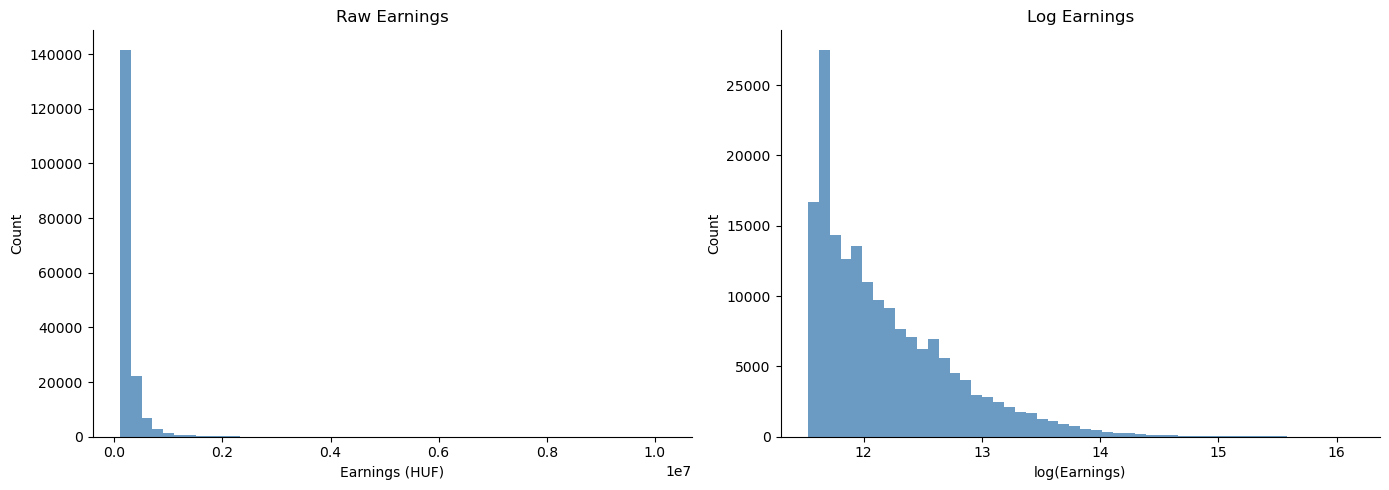

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw earnings
axes[0].hist(df['earnings'], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Raw Earnings')
axes[0].set_xlabel('Earnings (HUF)')
axes[0].set_ylabel('Count')

# Log earnings
axes[1].hist(df['log_earnings'], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_title('Log Earnings')
axes[1].set_xlabel('log(Earnings)')
axes[1].set_ylabel('Count')

plt.tight_layout()
# Save figure
plt.savefig("../figs/fig1_earnings_distribution.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [24]:
stats = df['earnings'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
stats.index = ['N', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
print(stats.round(0))
print(f'Raw earinings skewness: {df["earnings"].skew():.3f}')
print(f'Log earinings skewness: {df["log_earnings"].skew():.3f}')

N           177421.0000
Mean        244885.0000
Median      166000.0000
Std Dev     262620.0000
Min         101500.0000
Max       10180710.0000
Name: earnings, dtype: float64
Raw earinings skewness: 9.014
Log earinings skewness: 1.326


The raw earnings distribution is heavily right-skewed: the mean substantially exceeds the median, and the standard deviation is nearly as large as the mean itself, indicating a long right tail. The maximum value of 10.2M HUF is roughly 60 times the median. This is consistent with the well-documented log-normality of wage distributions in the labour economics literature, and motivates the use of log earnings as the outcome variable in all subsequent analyses. The log earnings skewness is around 1.3, a large reduction from the raw earnings skewness. While we could employ the use of a Box-Cox transform, we are prioritising interpretability as our question is around inference. Furthermore, this is an acceptable level of skewness in literature and by CLT and the large amount of observations we have, a log transform is concluded to be appropriate.

### 6.2 Earnings by Foreign Ownership

/tmp/ipykernel_3574831/1695324233.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups_log.values(), labels=groups_log.keys())


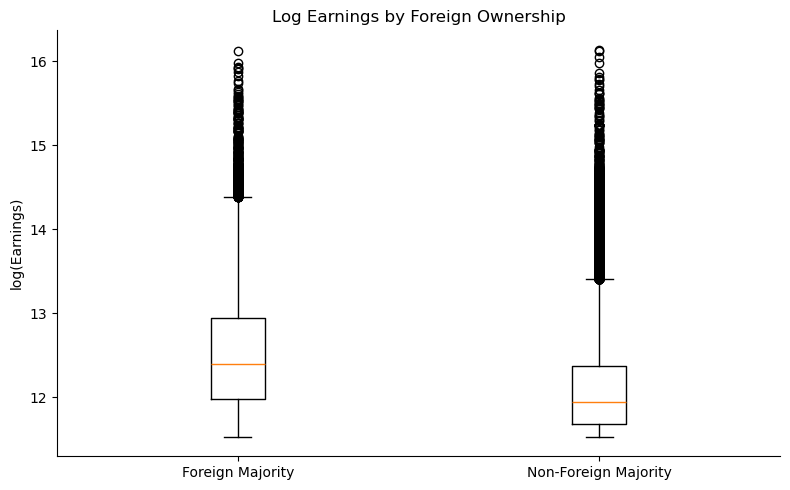

       Foreign Majority  Non-Foreign Majority
count        37108.0000           140313.0000
mean        358428.0000           214856.0000
std         384908.0000           209086.0000
min         101500.0000           101500.0000
10%         127521.0000           109100.0000
25%         159776.0000           118500.0000
50%         241497.0000           153804.0000
75%         416986.0000           236096.0000
90%         691667.0000           362108.0000
max       10027770.0000         10180710.0000


In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

groups_log = {
    'Foreign Majority': df[df['foreign_majority'].cat.codes == 1]['log_earnings'],
    'Non-Foreign Majority': df[df['foreign_majority'].cat.codes == 0]['log_earnings'],
}

ax.boxplot(groups_log.values(), labels=groups_log.keys())
ax.set_ylabel('log(Earnings)')
ax.set_title('Log Earnings by Foreign Ownership')

plt.tight_layout()
plt.savefig("../figs/fig2_log_earnings_foreign_ownership.png",
            dpi=300, bbox_inches='tight')
plt.show()

# Summary table in HUF
groups_raw = {
    'Foreign Majority': df[df['foreign_majority'].cat.codes == 1]['earnings'],
    'Non-Foreign Majority': df[df['foreign_majority'].cat.codes == 0]['earnings'],
}

summary = pd.DataFrame({
    name: grp.describe(percentiles=[.1, .25, .5, .75, .9])
    for name, grp in groups_raw.items()
}).round(0)
print(summary)

A first descriptive look reveals a substantial raw earnings gap between foreign-majority 
and non-foreign-majority firms. The median earnings at foreign-majority firms (241,552 HUF) 
are approximately 57% higher than at non-foreign-majority firms (153,908 HUF). The gap 
widens further up the distribution: at the 90th percentile, foreign-majority workers earn 
691,867 HUF versus 362,335 HUF nearly double. Both groups share the same minimum 
(101,500 HUF, the 2014 statutory minimum wage) confirming our cleaning step was effective. 
Note that these are unconditional differences. The Blinder-Oaxaca decomposition will 
later separate how much of this gap is attributable to worker composition versus 
differential returns to characteristics.

### 6.3. Functional Form: Continuous Predictors

Given the large sample size (~190,000 observations), scatterplots are uninformative 
due to severe overplotting. Instead, we use binned means plots: the x-axis variable 
is divided into quantile bins and we plot the mean log earnings within each bin. 
This approach cleanly reveals the underlying conditional mean function without 
distributional assumptions, and is standard practice for exploratory functional 
form analysis in large-scale labour economics datasets.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, var in zip(axes, ['age', 'experience', 'tenure_years', 'total_hours']):
    temp = df[['log_earnings', var]].dropna().copy()
    temp['bin'] = pd.qcut(temp[var], q=30, duplicates='drop')
    binned = temp.groupby('bin')['log_earnings'].mean()
    bin_centers = temp.groupby('bin')[var].mean()
    
    ax.plot(bin_centers, binned, color='steelblue', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel(var)
    ax.set_ylabel('Mean log(Earnings)')
    ax.set_title(f'Mean log(earnings) ~ {var}')

plt.tight_layout()
plt.savefig("../figs/fig3_binned_relationships_log_earnings.png",
            dpi=300, bbox_inches='tight')
plt.show()

**Age and experience** both display an inverted-U relationship with log earnings: 
earnings rise steeply in early career, peak around ages 35–40 (and ~15 years of 
experience), then gradually decline. This is the classic Mincer earnings profile 
and justifies including both the linear and squared terms for each variable.

**Tenure** shows a steep concave increase that flattens at higher values.The 
gains from an additional year of tenure diminish as tenure grows. This is 
characteristic of a log relationship, and indeed log(tenure + 1) produces a 
much more linear profile, justifying the log transformation.

**Total hours** displays a broadly linear positive relationship with log earnings: 
more hours worked is associated with higher earnings in an approximately proportional 
fashion, so no transformation is needed here.

In [ ]:
df['log_tenure'] = np.log(df['tenure_years'] + 1)

fig, ax = plt.subplots(figsize=(7, 5))

temp = df[['log_earnings', 'log_tenure']].dropna().copy()
temp['bin'] = pd.qcut(temp['log_tenure'], q=30, duplicates='drop')
binned = temp.groupby('bin')['log_earnings'].mean()
bin_centers = temp.groupby('bin')['log_tenure'].mean()

ax.plot(bin_centers, binned, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('log(tenure + 1)')
ax.set_ylabel('Mean log(Earnings)')
ax.set_title('log(earnings) ~ log(tenure + 1)')

plt.tight_layout()
plt.savefig("../figs/fig4_log_earnings_vs_log_tenure.png",
            dpi=300, bbox_inches='tight')
plt.show()

### Functional Form: Tenure

The binned means plot of log earnings against log(tenure + 1) reveals an 
approximately linear relationship, in contrast to the raw tenure variable which 
showed a steep concave curve. This confirms that the log transformation successfully 
linearises the tenure-earnings relationship, and we therefore use log(tenure + 1) 
as the regressor in all subsequent models.

### 6.4 Log Earnings by Binary Variables

In [ ]:
binary_cols = ['sex', 'fulltime', 'new_hire', 'collective_agreement', 
               'union_presence', 'any_supplement', 'foreign_majority', 'state_majority']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, binary_cols):
    sns.boxplot(data=df, x=col, y='log_earnings', ax=ax)
    ax.set_title(col)
    ax.set_ylabel('log(Earnings)')
    ax.set_xlabel('')
    ax.set_ylim(df['log_earnings'].quantile(0.01), df['log_earnings'].quantile(0.99))

plt.tight_layout()
plt.savefig("../figs/fig5_binary_vars_log_earnings_boxplots.png",
            dpi=300, bbox_inches='tight')
plt.show()

The boxplots reveal meaningful unconditional differences across several binary 
variables. The most striking gaps are for `foreign_majority`, confirming the 
raw wage premium observed earlier, and `any_supplement`, where recipients earn 
substantially more, likely reflecting higher-skill or more demanding roles. 
`collective_agreement` is also associated with higher earnings. In contrast, 
`fulltime` and `union_presence` show little unconditional difference, and 
`new_hire` workers earn somewhat less, consistent with returns to firm-specific 
tenure accumulating over time. The gender gap (sex) is visible but modest in 
the raw distribution.

### 6.5 Log Earnings by Categorical Variables

In [ ]:
cat_cols_plot = ['contract_type', 'settlement_type', 'education_5cat', 
                 'firm_size_4cat', 'position_5cat', 'industry_13cat']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols_plot):
    sns.boxplot(data=df, x=col, y='log_earnings', ax=ax)
    ax.set_title(col)
    ax.set_ylabel('log(Earnings)')
    ax.set_xlabel('')
    ax.set_ylim(df['log_earnings'].quantile(0.01), df['log_earnings'].quantile(0.99))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../figs/fig6_categorical_vars_log_earnings_boxplots.png",
            dpi=300, bbox_inches='tight')
plt.show()

The boxplots reveal clear and economically meaningful wage gradients across all 
categorical variables.

**Contract type**: permanent contracts are associated with higher earnings than 
fixed-term contracts, consistent with a compensating differential for job insecurity.

**Settlement type**: Budapest commands a substantial location premium over both towns 
and other settlements, reflecting higher productivity and cost of living in the capital.

**Education**: a strong monotonic gradient is visible — tertiary-educated workers earn 
roughly one log unit more than those with incomplete primary education, confirming the 
standard returns to schooling result.

**Firm size**: larger firms pay more across all size categories, consistent with the 
well-documented firm size wage premium in the labour economics literature.

**Position category**: the steepest gradient of all variables — top management earns 
approximately 1.5 log units more than manual workers, reflecting both skill and 
hierarchical wage-setting.

**Industry**: finance and ICT/professional services stand out as high-wage sectors, 
while agriculture, hospitality, and other services cluster at the bottom. Public 
administration, education, and health sit in the middle, consistent with compressed 
public sector wage scales.

### 6.6 Interaction Check: Returns to Continuous Predictors by Foreign Ownership


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# experience by foreign ownership
for own, grp in df.groupby('foreign_majority'):
    temp = grp[['log_earnings', 'experience']].dropna().copy()
    temp['bin'] = pd.qcut(temp['experience'], q=20, duplicates='drop')
    binned = temp.groupby('bin')['log_earnings'].mean()
    bin_centers = temp.groupby('bin')['experience'].mean()
    axes[0].plot(bin_centers, binned, marker='o', markersize=4, linewidth=2, label=f'foreign_majority={own}')

axes[0].set_xlabel('experience')
axes[0].set_ylabel('Mean log(Earnings)')
axes[0].set_title('Returns to experience by foreign ownership')
axes[0].legend()

# total_hours by foreign ownership
for own, grp in df.groupby('foreign_majority'):
    temp = grp[['log_earnings', 'total_hours']].dropna().copy()
    temp['bin'] = pd.qcut(temp['total_hours'], q=20, duplicates='drop')
    binned = temp.groupby('bin')['log_earnings'].mean()
    bin_centers = temp.groupby('bin')['total_hours'].mean()
    axes[1].plot(bin_centers, binned, marker='o', markersize=4, linewidth=2, label=f'foreign_majority={own}')

axes[1].set_xlabel('total_hours')
axes[1].set_ylabel('Mean log(Earnings)')
axes[1].set_title('Returns to total hours by foreign ownership')
axes[1].legend()

# log_tenure by foreign ownership
df['log_tenure'] = np.log1p(df['tenure_years'])
for own, grp in df.groupby('foreign_majority'):
    temp = grp[['log_earnings', 'log_tenure']].dropna().copy()
    temp['bin'] = pd.qcut(temp['log_tenure'], q=20, duplicates='drop')
    binned = temp.groupby('bin')['log_earnings'].mean()
    bin_centers = temp.groupby('bin')['log_tenure'].mean()
    axes[2].plot(bin_centers, binned, marker='o', markersize=4, linewidth=2, label=f'foreign_majority={own}')

axes[2].set_xlabel('log(tenure + 1)')
axes[2].set_ylabel('Mean log(Earnings)')
axes[2].set_title('Returns to tenure by foreign ownership')
axes[2].legend()

plt.tight_layout()
plt.savefig("../figs/fig7_returns_by_foreign_ownership.png",
            dpi=300, bbox_inches='tight')
plt.show()

To assess whether interaction terms between ownership type and worker characteristics 
are warranted, we plot the binned mean log earnings against key continuous predictors 
separately for foreign-majority and non-foreign-majority firms.

The results are striking. Across all three variables, foreign-majority firms exhibit 
a consistently higher level of log earnings: confirming the raw wage premium observed 
earlier. More importantly, the *slopes* also differ across ownership types:

**Experience**: foreign-majority firms show a steeper and earlier-peaking experience 
profile, suggesting that returns to experience are higher in foreign-owned firms. 
This provides strong motivation for including an experience × foreign_majority 
interaction term in the regression.

**Total hours**: the relationship is noisier, but foreign-majority workers earn more 
at every hours level, with a potentially different slope in the standard full-time 
range around 174 hours.

**Tenure**: both groups show a positive tenure gradient, but the slope appears 
steeper for non-foreign-majority firms at lower tenure levels, suggesting that 
long-serving workers in domestic firms accumulate relatively more firm-specific 
human capital rewards. The gap between the two groups narrows at higher tenure levels.

These differential slopes justify the inclusion of ownership × worker characteristic 
interaction terms, and will be formally tested in the Blinder-Oaxaca decomposition.

### 6.7 Interaction Check: Returns to Education and Position by Foreign Ownership


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.boxplot(data=df, x='education_5cat', y='log_earnings', hue='foreign_majority', ax=axes[0])
axes[0].set_title('Log Earnings by Education and Foreign Ownership')
axes[0].set_xlabel('')
axes[0].set_ylabel('log(Earnings)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(df['log_earnings'].quantile(0.01), df['log_earnings'].quantile(0.99))

sns.boxplot(data=df, x='position_5cat', y='log_earnings', hue='foreign_majority', ax=axes[1])
axes[1].set_title('Log Earnings by Position and Foreign Ownership')
axes[1].set_xlabel('')
axes[1].set_ylabel('log(Earnings)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(df['log_earnings'].quantile(0.01), df['log_earnings'].quantile(0.99))

plt.tight_layout()
plt.savefig("../figs/fig8_education_position_by_ownership.png",
            dpi=300, bbox_inches='tight')

**Education**: the foreign ownership wage premium is present across all education 
categories, but the gap appears to widen at higher education levels. Foreign-majority 
firms pay a particularly pronounced premium for tertiary-educated workers, suggesting 
that returns to education are higher in foreign-owned firms, consistent with the idea 
that multinationals disproportionately reward high-skill workers. This motivates an 
education × foreign_majority interaction term.

**Position**: the foreign premium is visible across all position categories but is 
most pronounced at the top: top management and senior managers at foreign-majority 
firms earn substantially more than their counterparts at domestic firms. Interestingly, 
the gap narrows for manual workers, suggesting that foreign ownership compresses the 
within-firm wage hierarchy relative to domestic firms. This differential slope across 
the position hierarchy further justifies interaction terms in the model.

In [ ]:
df.to_csv("../data/berek_update.csv", index=False)

---
## Next steps
- **Section 8:** Multicollinearity check (VIF)
- **Section 9:** Model specification — theory-driven + forward search
- **Section 10:** Eicker-Huber-White test → NLM vs HLM
- **Section 11:** Blinder-Oaxaca decomposition
